<a href="https://colab.research.google.com/github/cellrishi-code/machine_learning_code_demo/blob/main/isotonic_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original: [10 20 15 30 28 40 45 50]
Isotonic: [10.  17.5 17.5 29.  29.  40.  45.  50. ]


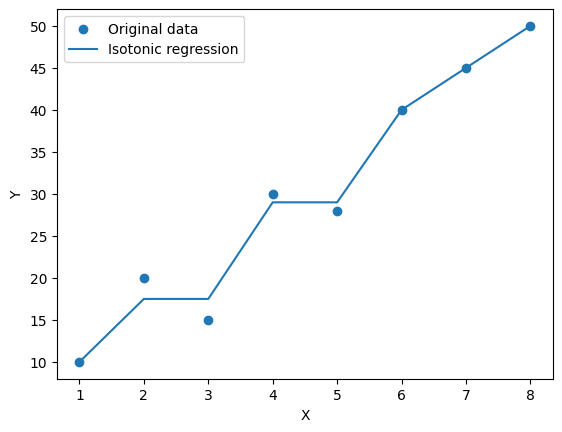

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression


x = np.array([1, 2, 3, 4, 5, 6, 7, 8])


y = np.array([10, 20, 15, 30, 28, 40, 45, 50])


model = IsotonicRegression(increasing=True)


model.fit(x, y)


y_pred = model.predict(x)

print("Original:", y)
print("Isotonic:", y_pred)


plt.scatter(x, y, label="Original data")
plt.plot(x, y_pred, label="Isotonic regression")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

Original:
[0.1  0.2  0.15 0.4  0.3  0.5  0.45 0.6  0.55 0.7  0.65 0.8  0.75 0.9
 0.95]

Isotonic:
[0.1   0.175 0.175 0.35  0.35  0.475 0.475 0.575 0.575 0.675 0.675 0.775
 0.775 0.9   0.95 ]


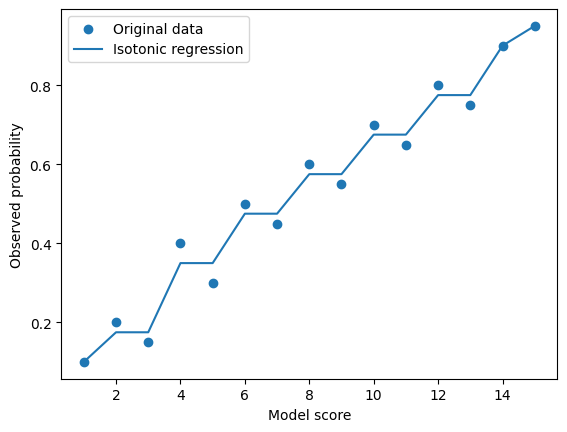

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def isotonic_regression(x, y):
    order = np.argsort(x)

    x = np.asarray(x)[order]
    y = np.asarray(y)[order]

    blocks = []

    for xi, yi in zip(x, y):
        block = {
            "x": [xi],
            "y": [yi],
            "weight": 1,
            "value": float(yi)
        }

        blocks.append(block)

        while len(blocks) >= 2:
            left = blocks[-2]
            right = blocks[-1]

            if left["value"] > right["value"]:
                total_weight = (
                    left["weight"] +
                    right["weight"]
                )

                weighted_average = (
                    left["value"] * left["weight"] +
                    right["value"] * right["weight"]
                ) / total_weight

                merged = {
                    "x": left["x"] + right["x"],
                    "y": left["y"] + right["y"],
                    "weight": total_weight,
                    "value": weighted_average
                }

                blocks = blocks[:-2]
                blocks.append(merged)
            else:
                break

    predictions = []

    for block in blocks:
        predictions.extend(
            [block["value"]] * block["weight"]
        )

    return x, np.array(predictions)


x = np.array([
    1, 2, 3, 4, 5,
    6, 7, 8, 9, 10,
    11, 12, 13, 14, 15
])

y = np.array([
    0.10,
    0.20,
    0.15,
    0.40,
    0.30,
    0.50,
    0.45,
    0.60,
    0.55,
    0.70,
    0.65,
    0.80,
    0.75,
    0.90,
    0.95
])

x_sorted, y_iso = isotonic_regression(x, y)

print("Original:")
print(y)

print("\nIsotonic:")
print(y_iso)

plt.scatter(
    x,
    y,
    label="Original data"
)

plt.plot(
    x_sorted,
    y_iso,
    label="Isotonic regression"
)

plt.xlabel("Model score")
plt.ylabel("Observed probability")
plt.legend()

plt.show()

In [ ]:
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import confusion_matrix


logger = logging.getLogger(__name__)


class Metrics(object):
    def __init__(self, df, thresholds=None):
        self.df = df
        self.y_true = df["label"] == 1
        self.thresholds = (
            thresholds
            if thresholds is not None
            else np.linspace(0.0, 1.0, 200, dtype=np.float32)
        )

    def at_threshold(self, threshold):
        self.y_pred = self.df["pred"] >= threshold
        cm = confusion_matrix(self.y_true, self.y_pred)

        tn = cm[0][0]
        fn = cm[1][0]
        tp = cm[1][1]
        fp = cm[0][1]

        precision = 1 if (tp + fp == 0) else tp / (tp + fp)
        recall = 1 if (tp + fn == 0) else tp / (tp + fn)
        fp_rate = 1 if (fp + tn == 0) else fp / (fp + tn)

        return [threshold, precision, recall, fp_rate]

    def at_all_thresholds(self):
        return [self.at_threshold(t) for t in self.thresholds]


def pos_ratio_at_threshold(from_threshold, to_threshold, predictions_and_labels):
    within_thresholds = predictions_and_labels[
        (predictions_and_labels["pred"] >= from_threshold)
        & (predictions_and_labels["pred"] < to_threshold)
    ]

    total = len(within_thresholds)
    pos_count = len(
        within_thresholds[within_thresholds["label"] == 1]
    )

    res = to_threshold if total == 0 else pos_count / total

    return res


def get_interval(score, thresholds):
    lower = max(i for i in thresholds if i < score)
    upper = min(i for i in thresholds if i > score)

    return lower, upper


def pos_ratio_for_score(score, predictions_and_labels, thresholds):
    from_t, to_t = get_interval(score, thresholds)

    return pos_ratio_at_threshold(
        from_t,
        to_t,
        predictions_and_labels
    )


def fit_isotonic_regression(predictions_and_labels, thresholds):
    X = predictions_and_labels["pred"].to_numpy()
    X = np.sort(X)

    y = [
        pos_ratio_for_score(
            x,
            predictions_and_labels,
            thresholds
        )
        for x in X
    ]

    y = np.array(y)

    iso_reg = IsotonicRegression(
        y_min=0,
        y_max=1,
        increasing=True,
        out_of_bounds="clip"
    ).fit(X, y)

    return iso_reg


def calibrate_scores(calibration_ds, thresholds):
    metrics = Metrics(
        calibration_ds,
        thresholds
    )

    iso_reg = fit_isotonic_regression(
        calibration_ds,
        thresholds
    )

    calibrated_probabilities = iso_reg.predict(
        metrics.thresholds
    )

    metrics_at_thresholds = metrics.at_all_thresholds()

    res_df = pd.DataFrame(
        metrics_at_thresholds,
        columns=[
            "thresholds_adult",
            "precision_at_thresholds_adult",
            "recall_at_thresholds_adult",
            "false_positive_rate_at_thresholds_adult",
        ],
    )

    res_df["probability_at_thresholds_adult"] = (
        calibrated_probabilities
    )

    return res_df


def calibrate_and_write_scores(config):
    calibration_ds = pd.read_csv(
        config.dataset_path,
        names=["pred", "label"],
        header=0
    )

    thresholds = np.linspace(
        0.0,
        1.0,
        config.num_thresholds,
        dtype=np.float32
    )

    res_df = calibrate_scores(
        calibration_ds,
        thresholds
    )

    output_file = (
        config.output_dir
        + "/metrics_at_thresholds.csv"
    )

    res_df.to_csv(
        output_file,
        index=False
    )

    plt.figure(figsize=(10, 6))

    plt.plot(
        res_df["thresholds_adult"],
        res_df["precision_at_thresholds_adult"],
        label="Precision"
    )

    plt.plot(
        res_df["thresholds_adult"],
        res_df["recall_at_thresholds_adult"],
        label="Recall"
    )

    plt.plot(
        res_df["thresholds_adult"],
        res_df["false_positive_rate_at_thresholds_adult"],
        label="False Positive Rate"
    )

    plt.xlabel("Threshold")
    plt.ylabel("Metric Value")
    plt.title("Precision, Recall and FPR vs Threshold")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        config.output_dir
        + "/metrics_vs_threshold.png"
    )

    plt.show()


if __name__ == "__main__":
    print("Calibration and plotting code loaded.")

Calibration and plotting code loaded.


In [4]:
import numpy as np
from sklearn.isotonic import IsotonicRegression

x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([1, 2, 2, 5, 4, 7])

model = IsotonicRegression()

model.fit(x, y)

predictions = model.predict(x)

print(predictions)

[1.  2.  2.  4.5 4.5 7. ]
